#Bhavin Bhatt
## Title: Olympic Data historical analysis
### Subtitle: Predicting right sport and athlete for Kellog's sponsorship



![Olympic_image_2](/content/Olympic_image.jpg

# 1) Objective
The proposed objective of this research is to analyse the historical data of Olympic games to find out the right sport and the athlete for Kellog's sponsorship.

First we would find out the medal tally data of every country and plot a graph displaying totals medals won by them.
We would also try to find out whether there is an increase in the medal tally for a country hosting an olympic game.
From this we would try to zero down on a country which has the most probability of winning the medals.

Secondly we would try to see the probability of males and females of winning any medals.
We will also try to analyse the relationship between height and weight in winning medalsfrom  the past historical data.

After predicting the country which has the highest probability of winning we can find out which sport that would fetch us maximum number of medals. This way we can pinpoint on the male and female athlete which can have the highest chances of winning medals for us and offer him the Kellog's sponsorship.



# 2) Data Exploration
  ##   Description
  2.1 Merging dataframe df1 which has athelete.csv and df2 which has noc_region.csv to a new dataframe df3.

  2.2 Col names from the final dataframe df3
  
  2.3 Dropping NA values from merged dataframe
  
  2.4 Getting the summary of dataframe df3 which would give us the length, mean, median and interquantile range of our dataset columns
  
  2.5 We will count the number of rows and columns in our dataframe.


  .

In [12]:
df1 <- read.csv("/content/athlete_events.csv")
#df1
head(df1)
dim(df1)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,1,A Dijiang,M,24,180,80,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NA
2,2,A Lamusi,M,23,170,60,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NA
3,3,Gunnar Nielsen Aaby,M,24,NA,NA,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NA
4,4,Edgar Lindenau Aabye,M,34,NA,NA,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
5,5,Christine Jacoba Aaftink,F,21,185,82,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NA
6,5,Christine Jacoba Aaftink,F,21,185,82,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NA


[1] 271116     15

In [13]:
library(tidyverse)
library(dplyr)
df2 <- read.csv("/content/noc_regions.csv")
df2[3] <- NULL
df2 <- df2%>%drop_na()
dim(df2)
colnames(df2)

[1] 227   2

[1] "NOC"    "region"

Observation: Here there were 3 NA columns which have been removed and Yemen has 3 NOC codes.
This might cause issues but since we are counting only the countries winning medal this discrepancy will not affect our operations since Yemen hasn't won any medals till date.

In [3]:
colnames(df1)
dim(df1)

[1] "ID"     "Name"   "Sex"    "Age"    "Height" "Weight" "Team"   "NOC"   
 [9] "Games"  "Year"   "Season" "City"   "Sport"  "Event"  "Medal"

[1] 82432    15

###2.1 We are now merging the Region dataframe(df2) with the Athlete dataframe(df1) to get the full form of the countries,
The final dataframe is named as df3 which consists of both our excel files in the dataset.

In [14]:
df3 <- merge(df1,df2, by ="NOC")
head(df3)
dim(df3)

,NOC,ID,Name,Sex,Age,Height,Weight,Team,Games,Year,Season,City,Sport,Event,Medal,region
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AFG,44977,Mohammad Halilula,M,28,163,57,Afghanistan,1980 Summer,1980,Summer,Moskva,Wrestling,"Wrestling Men's Bantamweight, Freestyle",NA,Afghanistan
2,AFG,502,Ahmad Shah Abouwi,M,NA,NA,NA,Afghanistan,1956 Summer,1956,Summer,Melbourne,Hockey,Hockey Men's Hockey,NA,Afghanistan
3,AFG,25470,Aka-Jahan Dastagir,M,22,170,70,Afghanistan,1968 Summer,1968,Summer,Mexico City,Wrestling,"Wrestling Men's Lightweight, Freestyle",NA,Afghanistan
4,AFG,5285,Mohammad Arref,M,NA,NA,52,Afghanistan,1972 Summer,1972,Summer,Munich,Wrestling,"Wrestling Men's Flyweight, Freestyle",NA,Afghanistan
5,AFG,1076,Jammal-ud-Din Affendi,M,28,NA,NA,Afghanistan,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,NA,Afghanistan
6,AFG,121376,Khan Nasrullah Totakhail,M,NA,NA,NA,Afghanistan,1956 Summer,1956,Summer,Melbourne,Hockey,Hockey Men's Hockey,NA,Afghanistan


[1] 270746     16

In [5]:
length(unique(df3$NOC))

[1] 224

###2.2 Col names from the final dataframe df3

In [6]:
colnames(df3)


[1] "NOC"    "ID"     "Name"   "Sex"    "Age"    "Height" "Weight" "Team"  
 [9] "Games"  "Year"   "Season" "City"   "Sport"  "Event"  "Medal"  "region"

###2.3 Getting the summary of dataframe df3 which gives us the length, median and interquantile range of the columns in our dataset.

In [7]:
summary(df3)

     NOC                  ID            Name               Sex           
 Length:82361       Min.   :    1   Length:82361       Length:82361      
 Class :character   1st Qu.:10867   Class :character   Class :character  
 Mode  :character   Median :21257   Mode  :character   Mode  :character  
                    Mean   :21195                                        
                    3rd Qu.:31648                                        
                    Max.   :41881                                        
                                                                         
      Age            Height          Weight           Team          
 Min.   :11.00   Min.   :127.0   Min.   : 25.00   Length:82361      
 1st Qu.:21.00   1st Qu.:168.0   1st Qu.: 61.00   Class :character  
 Median :24.00   Median :175.0   Median : 70.00   Mode  :character  
 Mean   :25.61   Mean   :175.5   Mean   : 70.86                     
 3rd Qu.:28.00   3rd Qu.:183.0   3rd Qu.: 79.00                

###2.4 Counting the number of rows and columns in our dataframe by dim() function

In [17]:
dim(df3)
library(tidyverse)
library(dplyr)

[1] 270746     16

#3) One column selection

 ### 3.1) To plot the countrywise medal tally we will create a new dataframe named medal_tally which has region and medal columns from the df3 dataframe.Here we would count the total number of medals won by any country.

 ### 3.2) medal_total - A dataframe which consists of top 10 countries which have won the highest number of medals till date.

In [26]:
library(tidyverse)
library(dplyr)
medal_tally <- df3[c("region","Medal")]

#Dropping NA values from Dataframe
medals <- medal_tally %>% drop_na()

#Counting gold, silver and Bronze medals
medal_tally <- medals%>%group_by(region, Medal)%>%summarize(Total=n())
head(medal_tally)

medal_total <- medals %>% group_by(region)%>%summarize(Total_Medal = n())%>%arrange(desc(Total_Medal))%>%head(n=30)
head(medal_total)


`summarise()` has grouped output by 'region'. You can override using the
`.groups` argument.


region,Medal,Total
<chr>,<chr>,<int>
Afghanistan,Bronze,2
Algeria,Bronze,8
Algeria,Gold,5
Algeria,Silver,4
Argentina,Bronze,91
Argentina,Gold,91


region,Total_Medal
<chr>,<int>
USA,5637
Russia,3947
Germany,3756
UK,2068
France,1777
Italy,1637


##medal_tally
Note: The dataframe medal_tally give us the total number of gold, silver and bronze medals for each country from the beginning of olympics in 1896 till date.

#4) Series
##Description
1. medal_tally : Analysing the highest number of medals in 3 categories won by countries till date from columns "region" and "medals"

2. medal_total : Analysing total number of medals won by countries till date to plot top 3 countries

2. medal_host : Counting the number of medals by each country each year from columns "region", "year", "medals", "game_location" by applying a function and replacing host cities by host countries to see whether there is an improvement in medal tally of host countries

3. Height_vs_Weight : We would group the dataframe by Age of athelete, sex, height, weight of athelete and their co-relation in winning medals

4. After concluding any country we would find out the sports that have won most number of medals for that particular country.


In [44]:
library(tidyverse)
medal_host <- df3 [c("region","Year", "City","Medal")]
#head(medal_host)

#Dropping NA values from Dataframe
library(tidyverse)
medal_host <- medal_host %>% drop_na(Medal)

head(medal_host)
dim(medal_host)

,region,Year,City,Medal
,<chr>,<int>,<chr>,<chr>
1,Afghanistan,2008,Beijing,Bronze
2,Afghanistan,2012,London,Bronze
3,Curacao,1988,Seoul,Silver
4,Algeria,1992,Barcelona,Gold
5,Algeria,1992,Barcelona,Bronze
6,Algeria,2016,Rio de Janeiro,Silver


[1] 39774     4

###Converting the Host cities to Host_countries so that it is easy to identify the country hosting olympics. Below we define a function and then apply it to our original medal_host dataframe to eliminate cities and replace it by Host_country column

In [45]:
host_country <- function(col) {
  if (col == "Rio de Janeiro") {
    return("Brazil")
  } else if (col == "London") {
    return("UK")
  } else if (col == "Beijing") {
    return("China")
  } else if (col == "Athina") {
    return("Greece")
  } else if (col %in% c("Sydney", "Melbourne")) {
    return("Australia")
  } else if (col %in% c("Atlanta", "Los Angeles", "St. Louis")) {
    return("USA")
  } else if (col == "Barcelona") {
    return("Spain")
  } else if (col == "Seoul") {
    return("South Korea")
  } else if (col == "Moskva") {
    return("Russia")
  } else if (col == "Montreal") {
    return("Canada")
  } else if (col %in% c("Munich", "Berlin")) {
    return("Germany")
  } else if (col == "Mexico City") {
    return("Mexico")
  } else if (col == "Tokyo") {
    return("Japan")
  } else if (col == "Roma") {
    return("Italy")
  } else if (col == "Paris") {
    return("France")
  } else if (col == "Helsinki") {
    return("Finland")
  } else if (col == "Amsterdam") {
    return("Netherlands")
  } else if (col == "Antwerpen") {
    return("Belgium")
  } else if (col == "Stockholm") {
    return("Sweden")
  } else {
    return("Other")
  }
}

#Load the dplyr package if not already loaded
library(dplyr)

# Apply the host_country function to create the Host_Country column
medal_host <- medal_host %>%
  mutate(Host_Country = sapply(City, host_country))

#head(medal_host)

In [46]:
#Creating a new column with Host as Yes or No so as to plot it in graph.
medal_host <- medal_host %>%
  mutate(Host = if_else(medal_host$region == medal_host$Host_Country, 'Yes', 'No'))

medal_host[3] <- NULL
#head(medal_host)
#dim(medal_host)

,region,Year,Medal,Host_Country,Host
,<chr>,<int>,<chr>,<chr>,<chr>
1,Afghanistan,2008,Bronze,China,No
2,Afghanistan,2012,Bronze,UK,No
3,Curacao,1988,Silver,South Korea,No
4,Algeria,1992,Gold,Spain,No
5,Algeria,1992,Bronze,Spain,No
6,Algeria,2016,Silver,Brazil,No


[1] 39774     5

In [47]:
medal_host[3] <- NULL
medal_host <- medal_host%>%group_by(region, Year, Host_Country, Host)%>%summarize(Total=n())%>%ungroup()
head(medal_host)

`summarise()` has grouped output by 'region', 'Year', 'Host_Country'. You can
override using the `.groups` argument.


region,Year,Host_Country,Host,Total
<chr>,<int>,<chr>,<chr>,<int>
Afghanistan,2008,China,No,1
Afghanistan,2012,UK,No,1
Algeria,1984,USA,No,2
Algeria,1992,Spain,No,2
Algeria,1996,USA,No,3
Algeria,2000,Australia,No,5


#From medal_host dataframe we would select the countries which have hosted the olympics till date to find out whether there is an improvement in their medal tally when hosting the games.

In [31]:
medal_host_final <- medal_host[medal_host$region %in% c("Brazil","UK","China","Greece","Australia","USA","Spain","South Korea","Russia","Canada","Germany","Mexico","Japan","Italy","France","Finland","Netherlands","Belgium","Sweden"),]

# 4) Series

In [35]:
#Getting the original dataframe df3
head(df3)

,NOC,ID,Name,Sex,Age,Height,Weight,Team,Games,Year,Season,City,Sport,Event,Medal,region
,<chr>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AFG,44977,Mohammad Halilula,M,28,163,57,Afghanistan,1980 Summer,1980,Summer,Moskva,Wrestling,"Wrestling Men's Bantamweight, Freestyle",NA,Afghanistan
2,AFG,502,Ahmad Shah Abouwi,M,NA,NA,NA,Afghanistan,1956 Summer,1956,Summer,Melbourne,Hockey,Hockey Men's Hockey,NA,Afghanistan
3,AFG,25470,Aka-Jahan Dastagir,M,22,170,70,Afghanistan,1968 Summer,1968,Summer,Mexico City,Wrestling,"Wrestling Men's Lightweight, Freestyle",NA,Afghanistan
4,AFG,5285,Mohammad Arref,M,NA,NA,52,Afghanistan,1972 Summer,1972,Summer,Munich,Wrestling,"Wrestling Men's Flyweight, Freestyle",NA,Afghanistan
5,AFG,1076,Jammal-ud-Din Affendi,M,28,NA,NA,Afghanistan,1936 Summer,1936,Summer,Berlin,Hockey,Hockey Men's Hockey,NA,Afghanistan
6,AFG,121376,Khan Nasrullah Totakhail,M,NA,NA,NA,Afghanistan,1956 Summer,1956,Summer,Melbourne,Hockey,Hockey Men's Hockey,NA,Afghanistan


4.1) We will try to analyse which athelete has most probability of winning by exploring from the past data and taking height, weight, sex, age, and medals won by them into consideration.

In [37]:
Athelete <- df3[c("Sex", "Age","Height", "Weight","Medal")]
#head(Athelete)

#Getting data of atheletes which have won the medals by dropping NA values from the Medal column

Atheletes <- Athelete[!is.na(Athelete$Medal), ]
#head(Atheletes,5)
#summary(Atheletes)

Height_vs_Weight = Athelete%>% drop_na("Height", "Weight", "Medal")
head(Height_vs_Weight,5)

,Sex,Age,Height,Weight,Medal
,<chr>,<int>,<int>,<dbl>,<chr>
1,M,21,183,63,Bronze
2,M,25,183,63,Bronze
3,F,24,158,49,Gold
4,M,19,165,60,Bronze
5,M,28,170,67,Silver


##We have 2 dataframes namely:
##1) Athelete - We will use to find median age of atheletes winning medals
##2) Height_vs_Weight - We will use to find relation between them for atheletes winning medals.

###Selecting the sport from the countries which have won highest number of medals. We namely come to two countries
1.USA - Since its medal tally is highest

2 France since the 2024 olympics is to be held in France and it is in top 10 countries plus it is hosting so its chances are more better

In [110]:
Sports <- df3[c('region','Sport','Medal')]%>% drop_na(Medal)

#Sports <- df3[c('region','Sport','Medal')]
#Sports %>% drop_na(Medal)

#Counting the total number of sports won by each country in each game
Sports_total_medal<- Sports %>% group_by(region,Sport)%>%summarize(Total_Medal = n())
#head(Sports_total_medal)

#Subsetting the dataset for USA region
Sports_total_medal_USA <- Sports_total_medal[Sports_total_medal$region %in% c('USA'),]%>%arrange(desc(Total_Medal))%>%head(n=10)
head(Sports_total_medal_USA)

#Similarly subsetting dataset for France Region
Sports_total_medal_France <- Sports_total_medal[Sports_total_medal$region %in% c('France'),]%>%arrange(desc(Total_Medal))%>%head(n=10)
head(Sports_total_medal_France)

`summarise()` has grouped output by 'region'. You can override using the
`.groups` argument.


region,Sport,Total_Medal
<chr>,<chr>,<int>
USA,Athletics,1080
USA,Swimming,1078
USA,Rowing,375
USA,Basketball,341
USA,Ice Hockey,276
USA,Gymnastics,194


region,Sport,Total_Medal
<chr>,<chr>,<int>
France,Fencing,310
France,Cycling,151
France,Rowing,119
France,Sailing,117
France,Athletics,116
France,Swimming,80


###We now have two datasets for sports which have won highest medals for countries USA and France. We will plot to find out which sport has earned us maximum medals

# 5) Plot

#Plotting the countries with highest number of medals

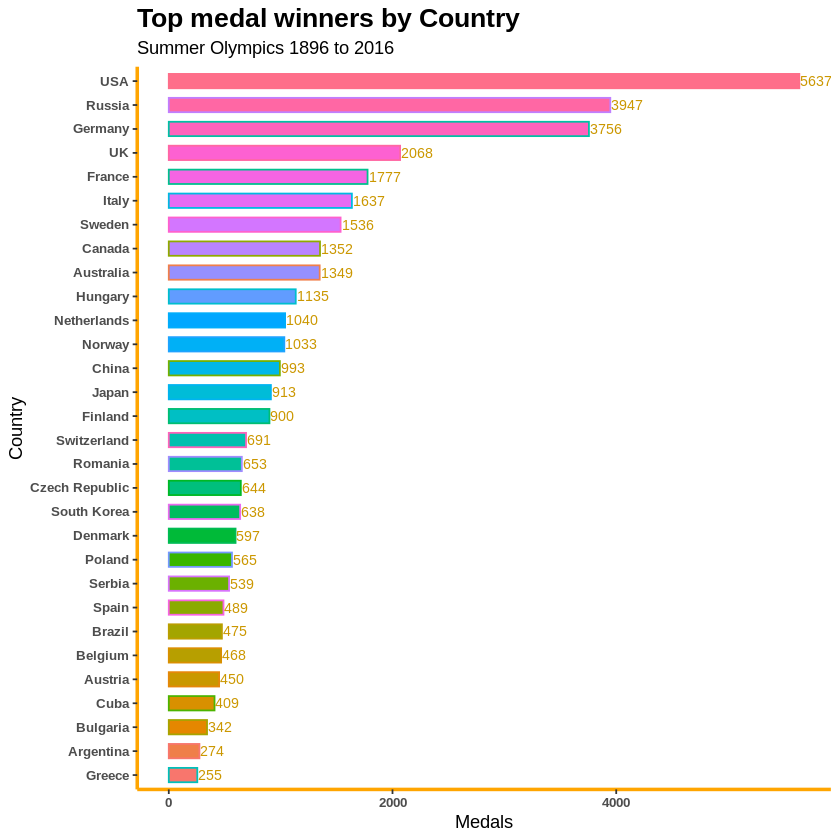

In [166]:
#Data wrangling for plotting countries with highest medals.
#head(medal_total)

#medal_total =medals%>%group_by(region)%>%summarize(total=n())%>%arrange(desc(total))%>%head(n=30)

#Arranging by region and total medals for plotting
medal_total$region <- factor(medal_total$region,levels = medal_total$region[order(medal_total$Total_Medal)])

#Plotting countries with highest medals

ggplot(medal_total,aes(region,Total_Medal,color=region,fill=region)) +
  geom_bar(position = "stack",  width =.6,stat="identity") +
  coord_flip()+
  geom_text(aes(label=Total_Medal,hjust=-.03,  colour="black"),size=3)+

  theme(axis.line = element_line(color = "orange",size=1))+
      theme(panel.background=element_blank())+
      scale_x_discrete() +
    xlab("Country")+ylab("Medals")+
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=16,face = "bold")) +
  ggtitle("Top medal winners by Country", subtitle= "Summer Olympics 1896 to 2016")

###Observation: From the above dataset we can see top 30 countries which have won us the highest number of medals in which USA is at the top of the chart.


### Plotting data of host countries when they hosted a game vs when they didn't to see whether there is a home advantage

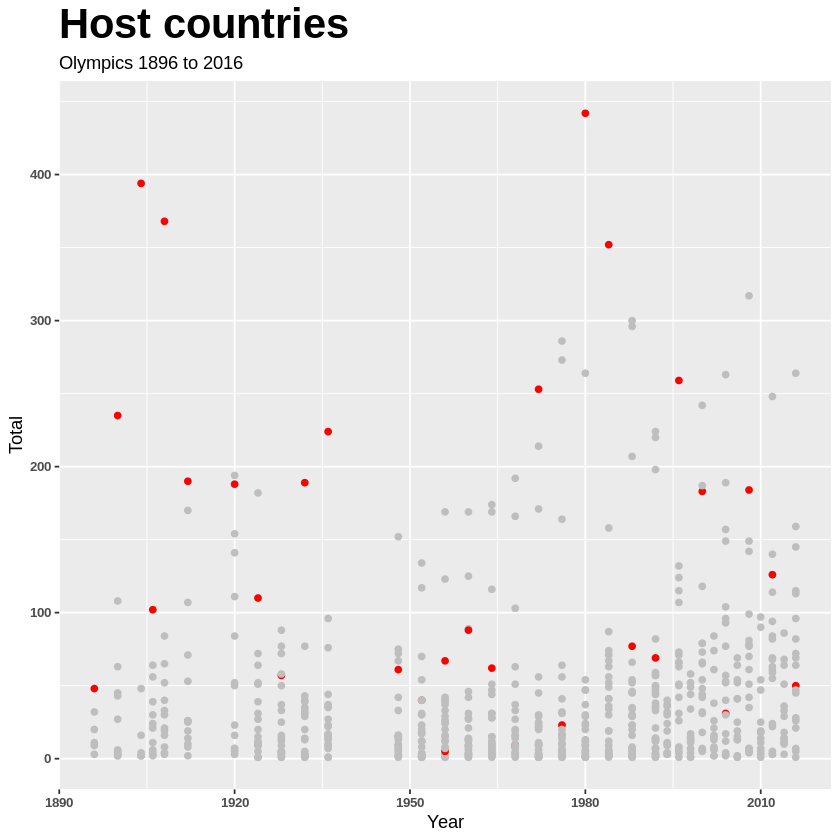

In [167]:
library(tidyverse)
library(ggplot2)
#theme_set(theme_gray(base_size=10))
ggplot(medal_host_final,aes(x = Year, y = Total, group= Host)) +
  geom_point(aes(color=Host))+
  scale_color_manual(values=c('grey','Red')) +
  ggtitle("Plot with right sided Title") +
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("Host countries", subtitle= "Olympics 1896 to 2016")


### Red dots denote host country medals.
### We can ignore the developed nations to see whether there is a home advantage in hosting olympics since these are developed nations and they already have a better sports infrastructure.
### We will try to plot graphs for developing economies such as Brazil and China to examine our case.

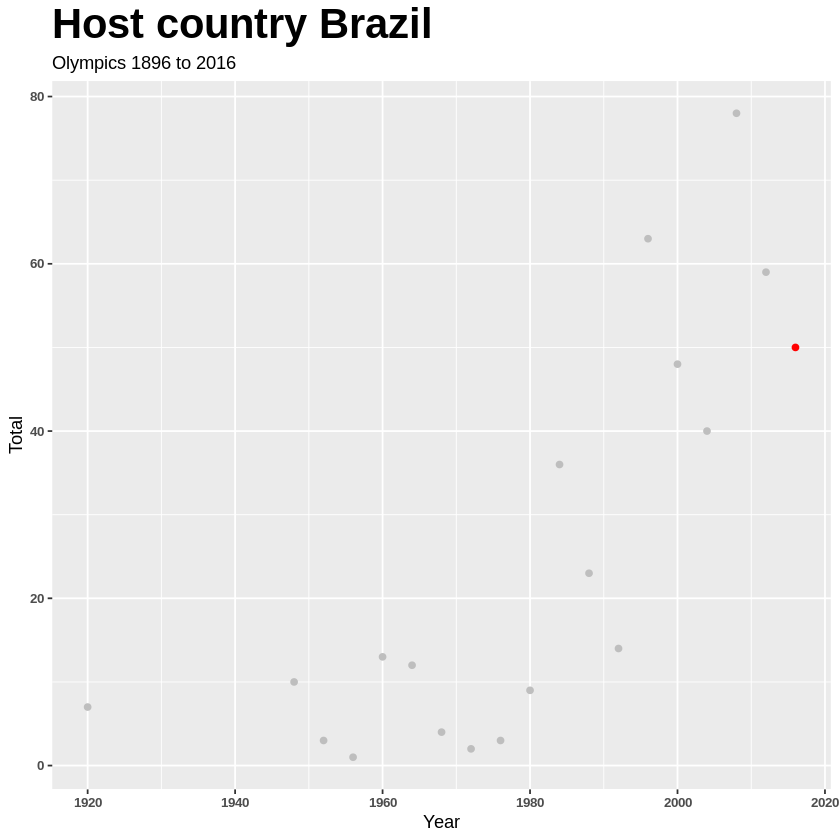

In [72]:
#Scatter plot of medals tally of Brazil hosting vs not hosting olympics
library(tidyverse)
library(ggplot2)
#theme_set(theme_gray(base_size=10))
ggplot(medal_host_final_Brazil,aes(x = Year, y = Total, group= Host)) +
  geom_point(aes(color=Host))+
  scale_color_manual(values=c('grey','Red'))+
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("Host country Brazil", subtitle= "Olympics 1896 to 2016")

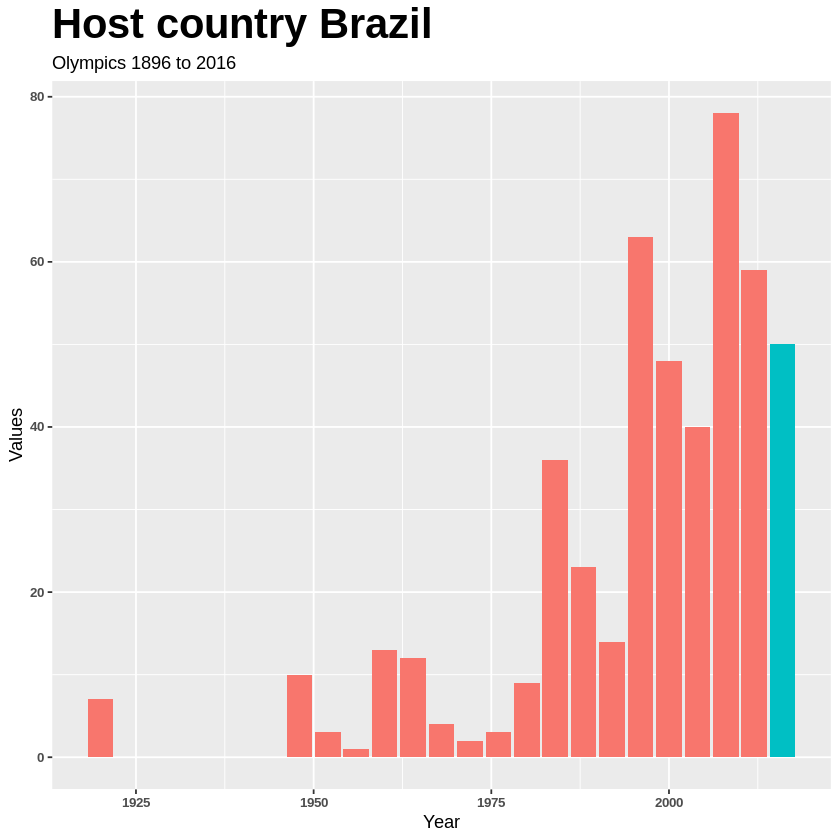

In [77]:
#Plotting bar chart for Brazil when it is hosting vs not hosting
library(ggplot2)

# Create a data frame
#Plotting USA medals tally it hosted vs not hosted.
medal_host_final_Brazil <- medal_host_final[medal_host_final$region %in% c("Brazil"),]
#head(medal_host_final_Brazil)

# Create a bar chart using ggplot2
ggplot(medal_host_final_Brazil, aes(x = Year, y = Total, fill = Host)) +
  geom_bar(stat = "identity") +
  labs(title = "Total Medal", x = "Year", y = "Values") +
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("Host country Brazil", subtitle= "Olympics 1896 to 2016")



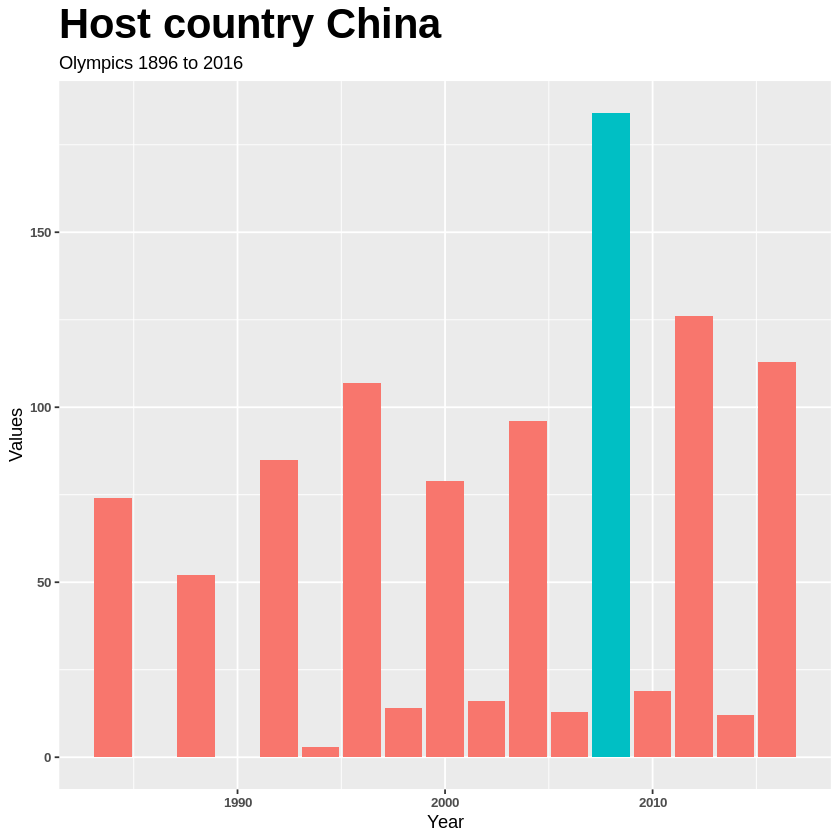

In [80]:
#Plotting bar chart for Brazil when it is hosting vs not hosting
library(ggplot2)

# Create a data frame
#Plotting USA medals tally it hosted vs not hosted.
medal_host_final_China <- medal_host_final[medal_host_final$region %in% c("China"),]
#head(medal_host_final_China)

# Create a bar chart using ggplot2
ggplot(medal_host_final_China, aes(x = Year, y = Total, fill = Host)) +
  geom_bar(stat = "identity") +
  labs(title = "Total Medal", x = "Year", y = "Values") +
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("Host country China", subtitle= "Olympics 1896 to 2016")



###It can be observed from the above that countries hosting olympics have a home advantage.

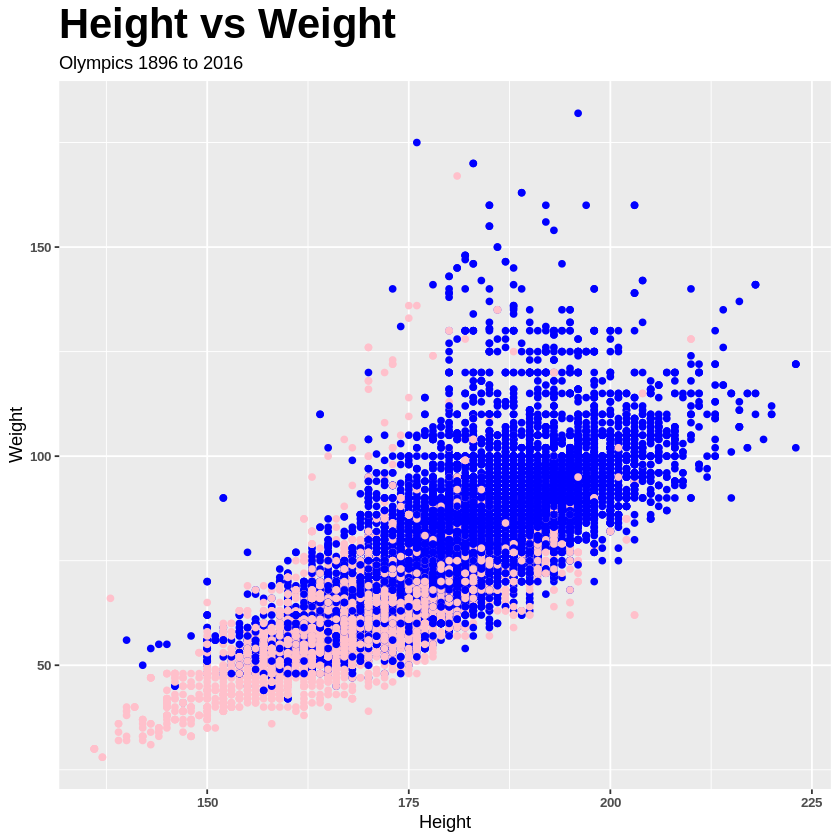

In [83]:
#Plotting Height_vs_Weight
library(tidyverse)
#Height_vs_Weight %>% ggplot(aes(x = Height, y = Weight), col= Height_vs_Weight$Sex) + geom_point()
library(ggplot2)
ggplot(Height_vs_Weight,aes(x=Height,y=Weight,group=Sex))+
   geom_point(aes(color=Sex))+
   scale_color_manual(values=c('Pink','Blue'))+
   theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("Height vs Weight", subtitle= "Olympics 1896 to 2016")

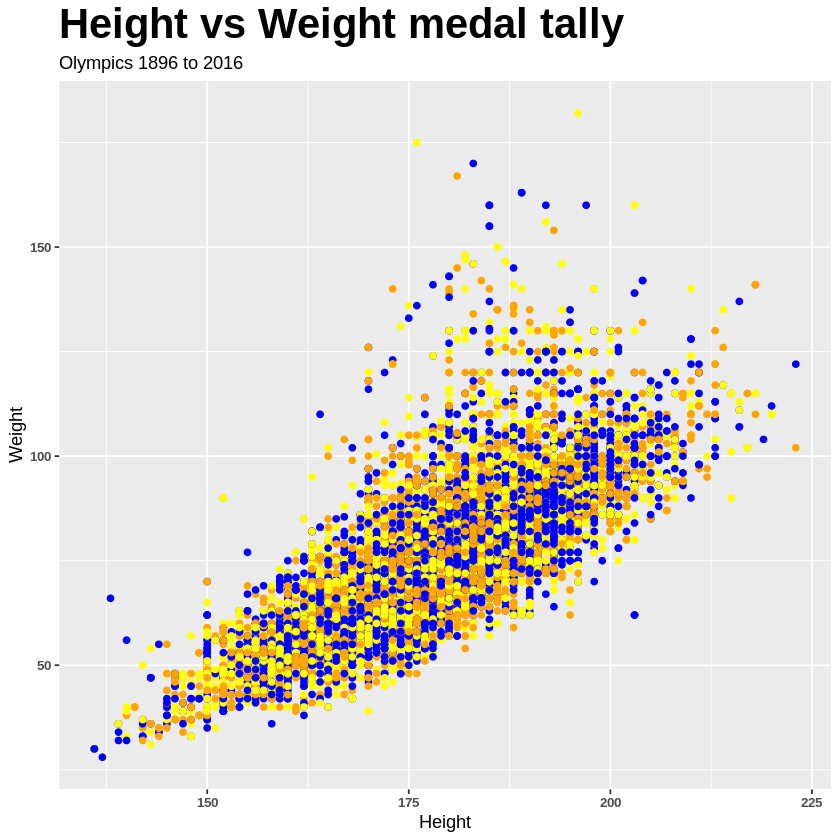

In [85]:
#Plotting Height_vs_weight ofatheletes vs medals they won
library(tidyverse)
library(ggplot2)
ggplot(Height_vs_Weight,aes(x=Height,y=Weight,group=Medal))+
   geom_point(aes(color= Medal))+
   scale_color_manual(values=c('Yellow','Blue','orange'))+
   theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("Height vs Weight medal tally", subtitle= "Olympics 1896 to 2016")

###Observation: It can be observed that the relationship between weight and height is linear for athelete winning medals. It can also be oberved that for most male atheletes fall in height range of 175cm to 200cm and weight range of 75 to 100 kg.For most female atheletes Height rangeis 15cm to 175cm and weight range is 25 to 75kgs

In [105]:
head(Sports_total_medal_USA)
dim(Sports_total_medal_USA)

#Sports_total_medal_France

region,Sport,Total_Medal
<chr>,<fct>,<int>
USA,Alpine Skiing,44
USA,Archery,57
USA,Art Competitions,9
USA,Athletics,1080
USA,Baseball,68
USA,Basketball,341


[1] 51  3

region,Sport,Total_Medal
<chr>,<fct>,<int>
USA,Alpine Skiing,44
USA,Archery,57
USA,Art Competitions,9
USA,Athletics,1080
USA,Baseball,68


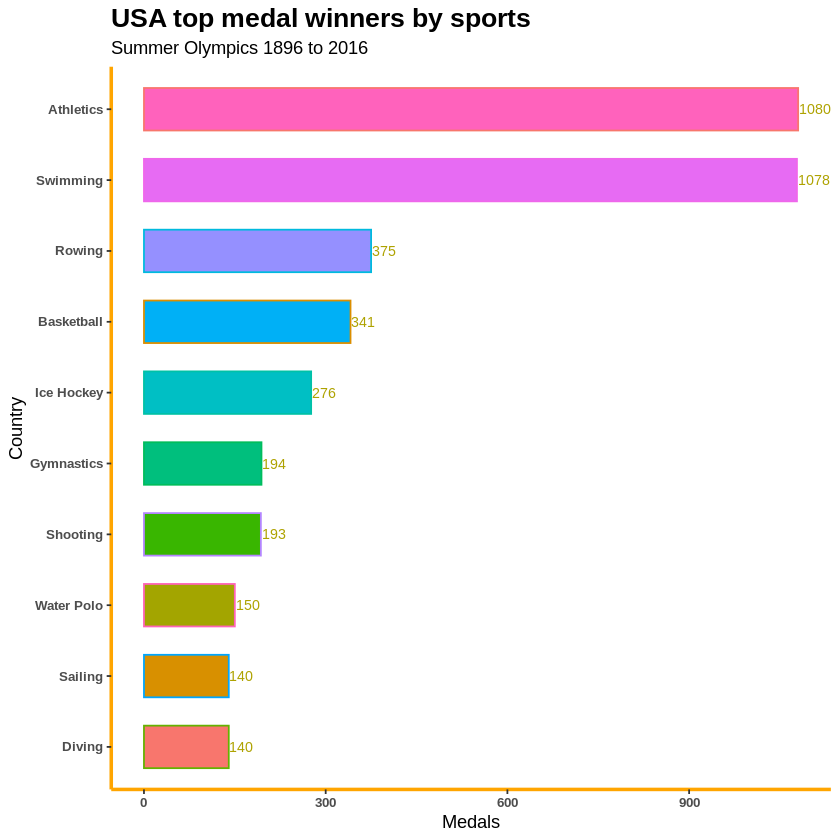

In [117]:
#Arranging by Sport and total medals for plotting
#Selecting top 5 sports in our dataframe
Sports_total_medal_USA$Sport <- factor(Sports_total_medal_USA$Sport,levels = Sports_total_medal_USA$Sport[order(Sports_total_medal_USA$Total_Medal)])

#Plotting countries with highest medals

ggplot(Sports_total_medal_USA,aes(Sport,Total_Medal,color=Sport,fill=Sport)) +
  geom_bar(position = "stack",  width =.6,stat="identity") +
  coord_flip()+
  geom_text(aes(label=Total_Medal,hjust=-.03,  colour="black"),size=3)+

  theme(axis.line = element_line(color = "orange",size=1))+
      theme(panel.background=element_blank())+
      scale_x_discrete() +
    xlab("Country")+ylab("Medals")+
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=16,face = "bold")) +
  ggtitle("USA top medal winners by sports", subtitle= "Summer Olympics 1896 to 2016")

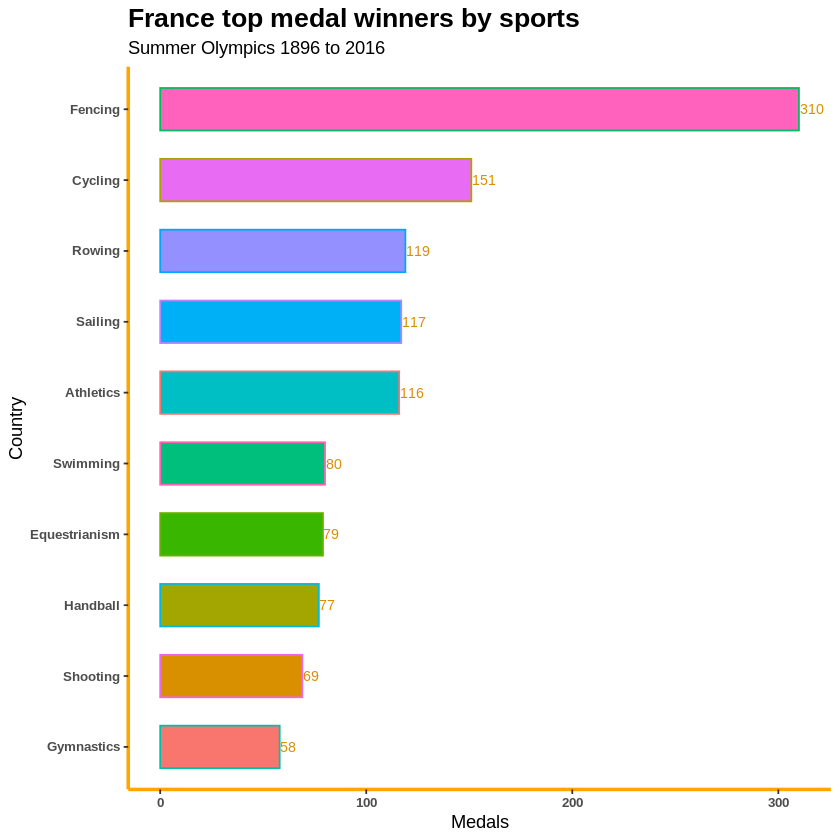

In [115]:
#Arranging by Sport and total medals for plotting
#Selecting top 5 sports in our dataframe
Sports_total_medal_France$Sport <- factor(Sports_total_medal_France$Sport,levels = Sports_total_medal_France$Sport[order(Sports_total_medal_France$Total_Medal)])

#Plotting countries with highest medals

ggplot(Sports_total_medal_France,aes(Sport,Total_Medal,color=Sport,fill=Sport)) +
  geom_bar(position = "stack",  width =.6,stat="identity") +
  coord_flip()+
  geom_text(aes(label=Total_Medal,hjust=-.03,  colour="black"),size=3)+

  theme(axis.line = element_line(color = "orange",size=1))+
      theme(panel.background=element_blank())+
      scale_x_discrete() +
    xlab("Country")+ylab("Medals")+
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=16,face = "bold")) +
  ggtitle("France top medal winners by sports", subtitle= "Summer Olympics 1896 to 2016")

Thus the sports which have most medal for countries are as follows:
1. USA - Athletics
2. France - Fencing

##Finding Athelete in USA

`summarise()` has grouped output by 'Name'. You can override using the
`.groups` argument.


Name,Sex,Medal
<chr>,<chr>,<int>
"Frederick Carlton ""Carl"" Lewis",M,10
"Raymond Clarence ""Ray"" Ewry",M,10
Allyson Michelle Felix,F,9


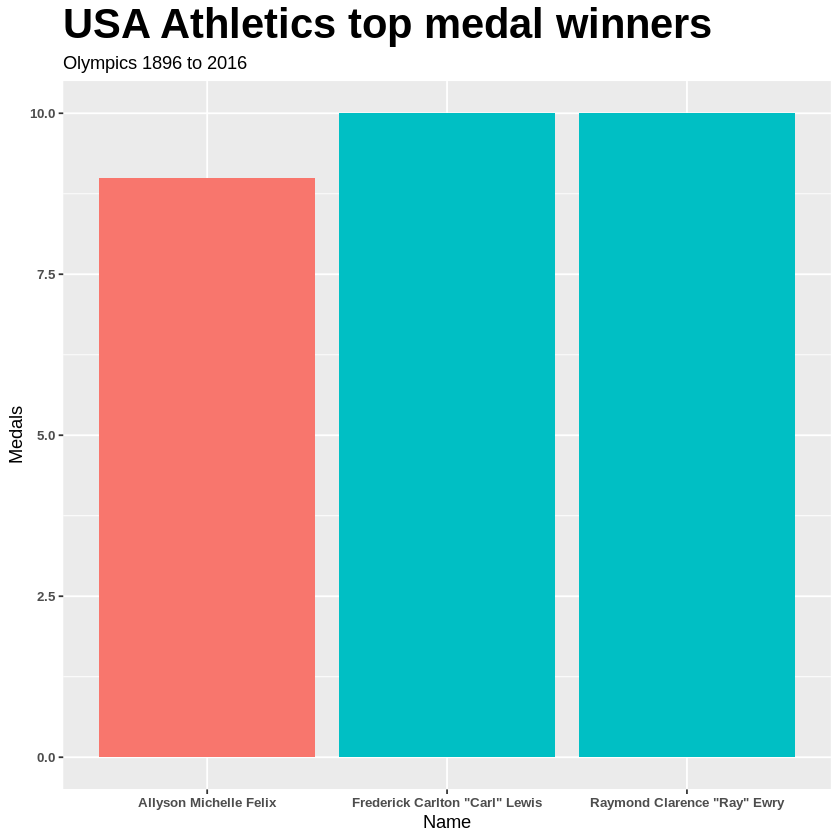

In [130]:
#Finding Atheletes in both the sports for our sponsorship

Sports_all <- df3[c('region', 'Name', 'Sex', 'Sport', 'Medal')]%>% drop_na(Medal)
#head(Sports_all)

Sports_USA <- Sports_all[Sports_all$region %in% c('USA'),]
Sports_USA <- Sports_USA[Sports_USA$Sport %in% c('Athletics'),]
#head(Sports_USA)

USA_athlete <- Sports_USA %>% group_by(Name,Sex)%>% summarize(Medal = n()) %>% arrange(desc(Medal))%>%head(n=3)
#head(USA_athlete)

#Plotting bar chart for Brazil when it is hosting vs not hosting
library(ggplot2)
# Create a bar chart using ggplot2
ggplot(USA_athlete, aes(x = Name, y = Medal, fill = Sex)) +
  geom_bar(stat = "identity") +
  labs(title = "USA Athletics top medal winners", x = "Name", y = "Medals") +
  theme(legend.position = "none",
                     axis.text = element_text(size = 8,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("USA Athletics top medal winners", subtitle= "Olympics 1896 to 2016")




##Finding Athelete in France

`summarise()` has grouped output by 'Name'. You can override using the
`.groups` argument.


Name,Sex,Medal
<chr>,<chr>,<int>
Philippe Louis Eugne Cattiau,M,8
Roger Franois Ducret,M,8
Christian Marie Auguste d'Oriola,M,6


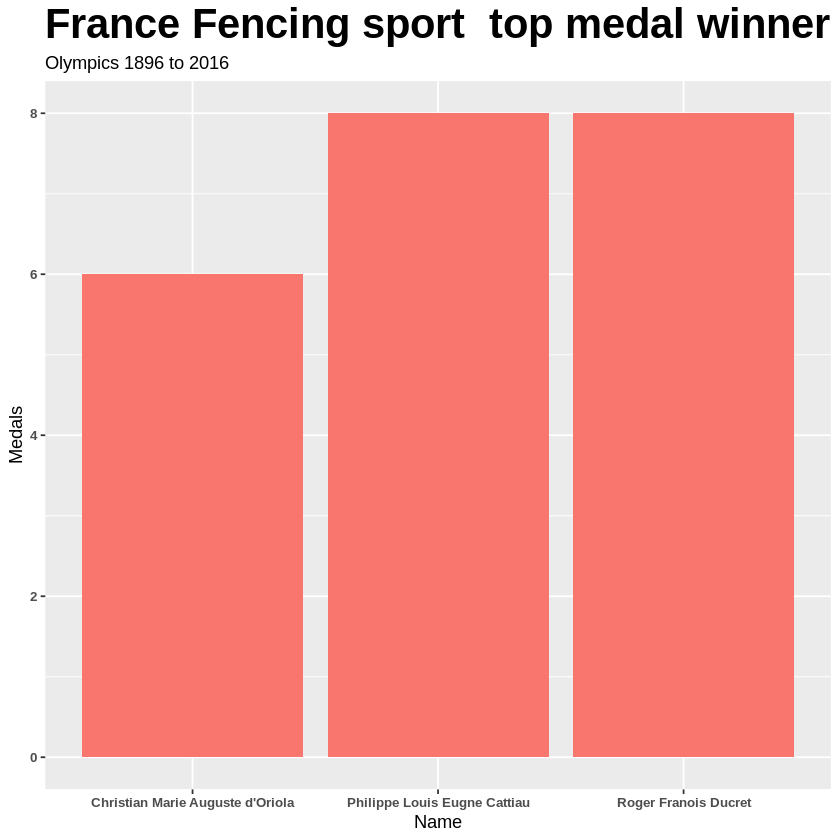

In [146]:
#Finding Atheletes in both the sports for our sponsorship

Sports_all <- df3[c('region', 'Name', 'Sex', 'Sport', 'Medal')]%>% drop_na(Medal)
#head(Sports_all)

Sports_France <- Sports_all[Sports_all$region %in% c('France'),]
Sports_France <- Sports_France[Sports_France$Sport %in% c('Fencing'),]%>%drop_na()
#head(Sports_France)
France_athlete <- Sports_France %>% group_by(Name,Sex)%>% summarize(Medal = n()) %>% arrange(desc(Medal))%>%head(n=3)
head(France_athlete)
#Plotting bar chart for Brazil when it is hosting vs not hosting
library(ggplot2)
# Create a bar chart using ggplot2
ggplot(France_athlete, aes(x = Name, y = Medal, fill = Sex)) +
  geom_bar(stat = "identity") +
  labs(title = "France Fencing sport top medal winner", x = "Name", y = "Medals") +
  theme(legend.position = "none",
                     axis.text = element_text(size = 8 ,face="bold"),
        plot.title = element_text(size=25,face = "bold")) +
  ggtitle("France Fencing sport  top medal winner", subtitle= "Olympics 1896 to 2016")


Thus the graphs give us top medal winners for USA and France with both Male and Female Atheletes

#6) Summary

1) After applying various methods first we found a country with highest number of medals which is USA and the host country France.

2) We also found out the relationship between height and weight for atheletes winning medals. From scatter plot we found the relationship linear and height and weight. For most male atheletes fall in height range of 175cm to 200cm and weight range of 75 to 100 kg.For most female atheletes Height range is 15cm to 175cm and weight range is 25 to 75kgs.

3) We also found the sports winning most number of medals in these countries and we came to a conclusion as below:
USA - Athletics sport
France - Fencing sport

4) After that we found the corresponding atheletes winning most medals in these countries. We each selected male and feamle atheletes from both sports since our focus is on women empowerment.

#7) Recommendation

In [165]:
Athelete_recommended <- df3[c('region','Name','Sex','Sport')]
Athelete_names_table <- Athelete_recommended [Athelete_recommended$Name %in% c('Frederick Carlton "Carl" Lewis','Raymond Clarence "Ray" Ewry', 'Allyson Michelle Felix','Philippe Louis Eugne Cattiau','Roger Franois Ducret',"Christian Marie Auguste d'Oriola"),]


Athelete_names_table%>%group_by(region,Name, Sex)%>%summarize(n=n())
Athelete_names_table[4] <- NULL

`summarise()` has grouped output by 'region', 'Name'. You can override using
the `.groups` argument.


region,Name,Sex,n
<chr>,<chr>,<chr>,<int>
France,Christian Marie Auguste d'Oriola,M,9
France,Philippe Louis Eugne Cattiau,M,11
France,Roger Franois Ducret,M,12
USA,Allyson Michelle Felix,F,10
USA,"Frederick Carlton ""Carl"" Lewis",M,10
USA,"Raymond Clarence ""Ray"" Ewry",M,10


Thus the atheletes above from countries USA and France would be our recommendation for the Kellog's sponsorhip due to their previous record and their countries have a high probability of winning the medals.